<a href="https://colab.research.google.com/github/pavanajayan/asteroid-diameter-prediction/blob/main/EXIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TASK 1

#Import libraries

In [ ]:

import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#load the dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI_ML/Data/asteroid.zip")
df

/tmp/ipykernel_1724/3830378261.py:1: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/AI_ML/Data/asteroid.zip")


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,bPLS6013,3246801,(6013 P-L),6013 P-L,NaN,NaN,N,N,17.135,NaN,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,MBA,0.23839
958520,bPLS6331,3246834,(6331 P-L),6331 P-L,NaN,NaN,N,N,18.500,NaN,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,MBA,0.53633
958521,bPLS6344,3013075,(6344 P-L),6344 P-L,NaN,NaN,Y,Y,20.400,NaN,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,APO,0.51556
958522,bT2S2060,3246457,(2060 T-2),2060 T-2,NaN,NaN,N,N,18.071,NaN,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,MBA,0.25641


#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [ ]:
df.shape

(958524, 45)

In [ ]:
df.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [ ]:
df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

#identify categorical and numerical features

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
print("Numerical columns:")
print(numerical_columns)

Numerical columns:
Index(['spkid', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch',
       'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad',
       'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e',
       'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma',
       'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms'],
      dtype='object')


In [ ]:
print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id',
       'equinox', 'class'],
      dtype='object')


In [ ]:
corr_with_diameter = (
    numeric_df.corr()["diameter"]
    .drop("diameter")
    .abs()
    .sort_values(ascending=False)
)

print(corr_with_diameter.head(10))

H                 0.572648
diameter_sigma    0.337145
moid              0.331983
moid_ld           0.331983
q                 0.329223
n                 0.199425
rms               0.182322
a                 0.146799
albedo            0.108880
spkid             0.095362
Name: diameter, dtype: float64


##ANALYTICAL

In [ ]:
1.NO TARGET IS NOT NORMALY DITRIBUTED
2.H HAS STRONG sns.relation
3.Orbital characteristics do not directly determine asteroid diameter. However, they can show statistical relationships with diameter because asteroids in different orbital populations can have different size distributions, and observational/detection effects also influence which asteroids are measured

#TASK2

#PREPROCESSING

In [ ]:
df.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["diameter"].value_counts()

,count
diameter,
4.017,45
3.296,45
3.122,44
3.537,44
3.008,44
...,...
0.124,1
0.055,1
0.057,1


#visualization

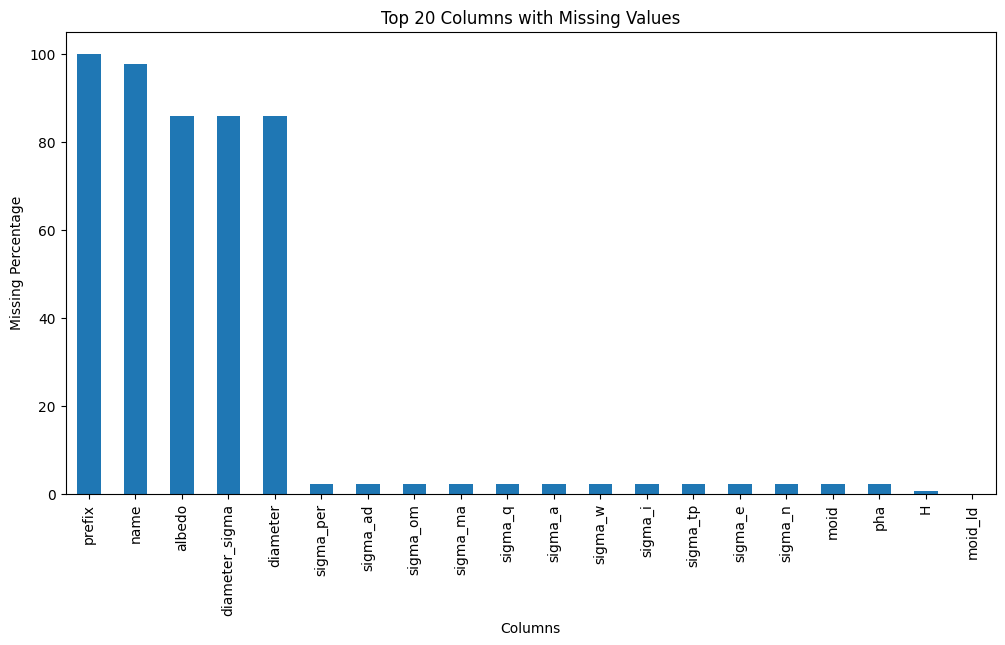

In [ ]:
plt.figure(figsize=(12, 6))

missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage.sort_values(ascending=False).head(20).plot(kind="bar")

plt.title("Top 20 Columns with Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)

plt.show()

#HISTOGRAM

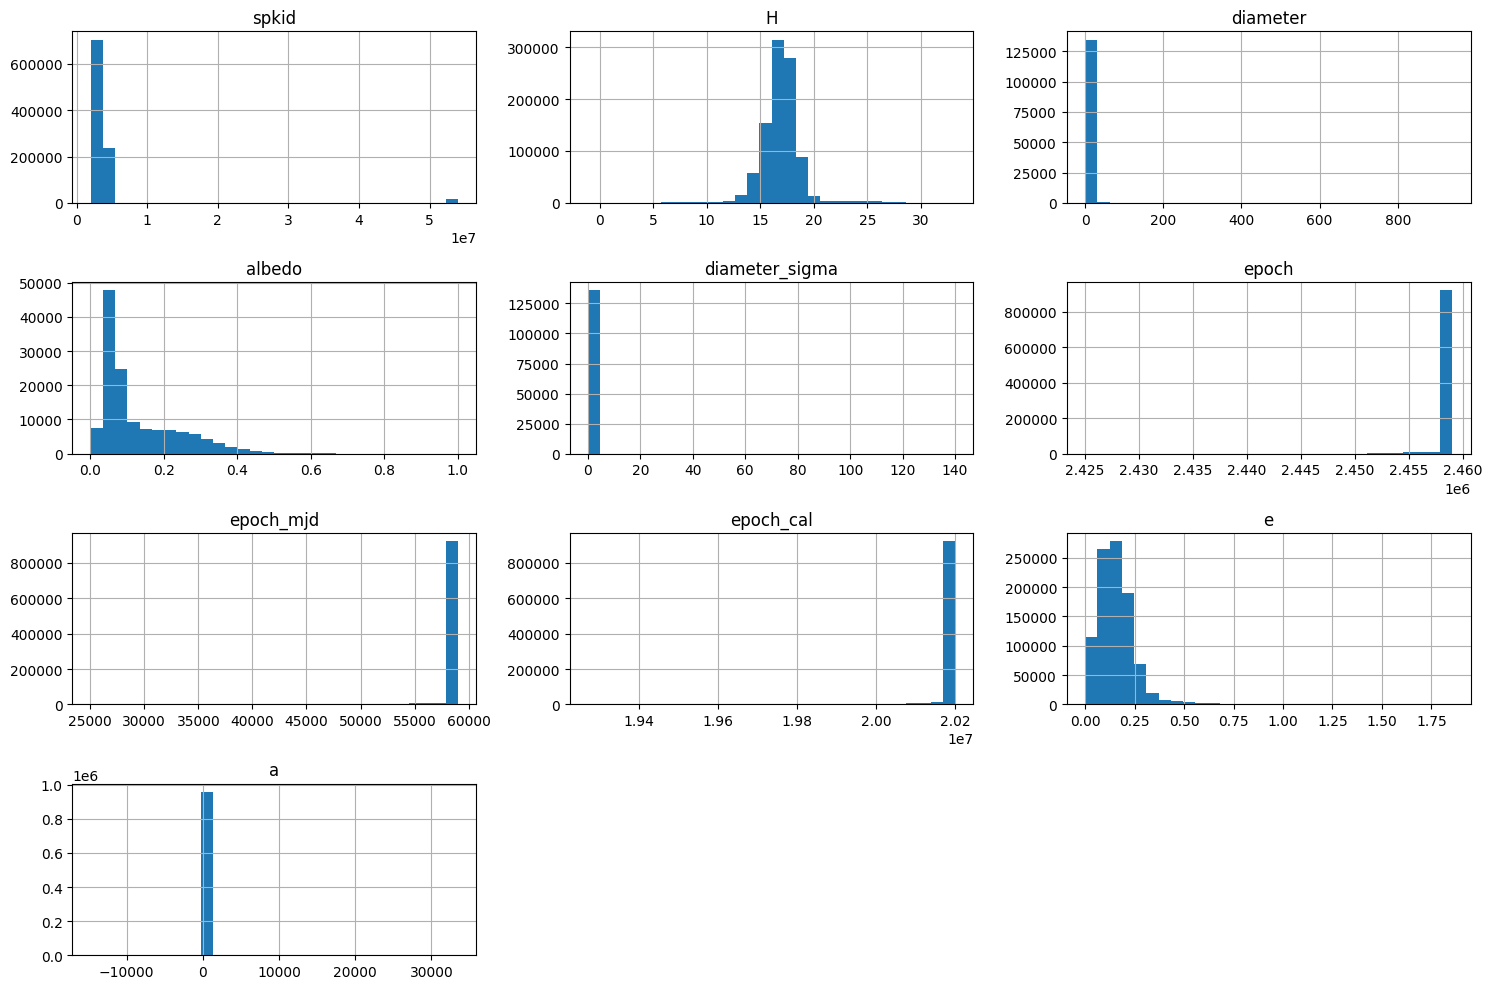

In [ ]:
df[numerical_columns[:10]].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

#BOXPLOT

##OUTLIER DETECTION

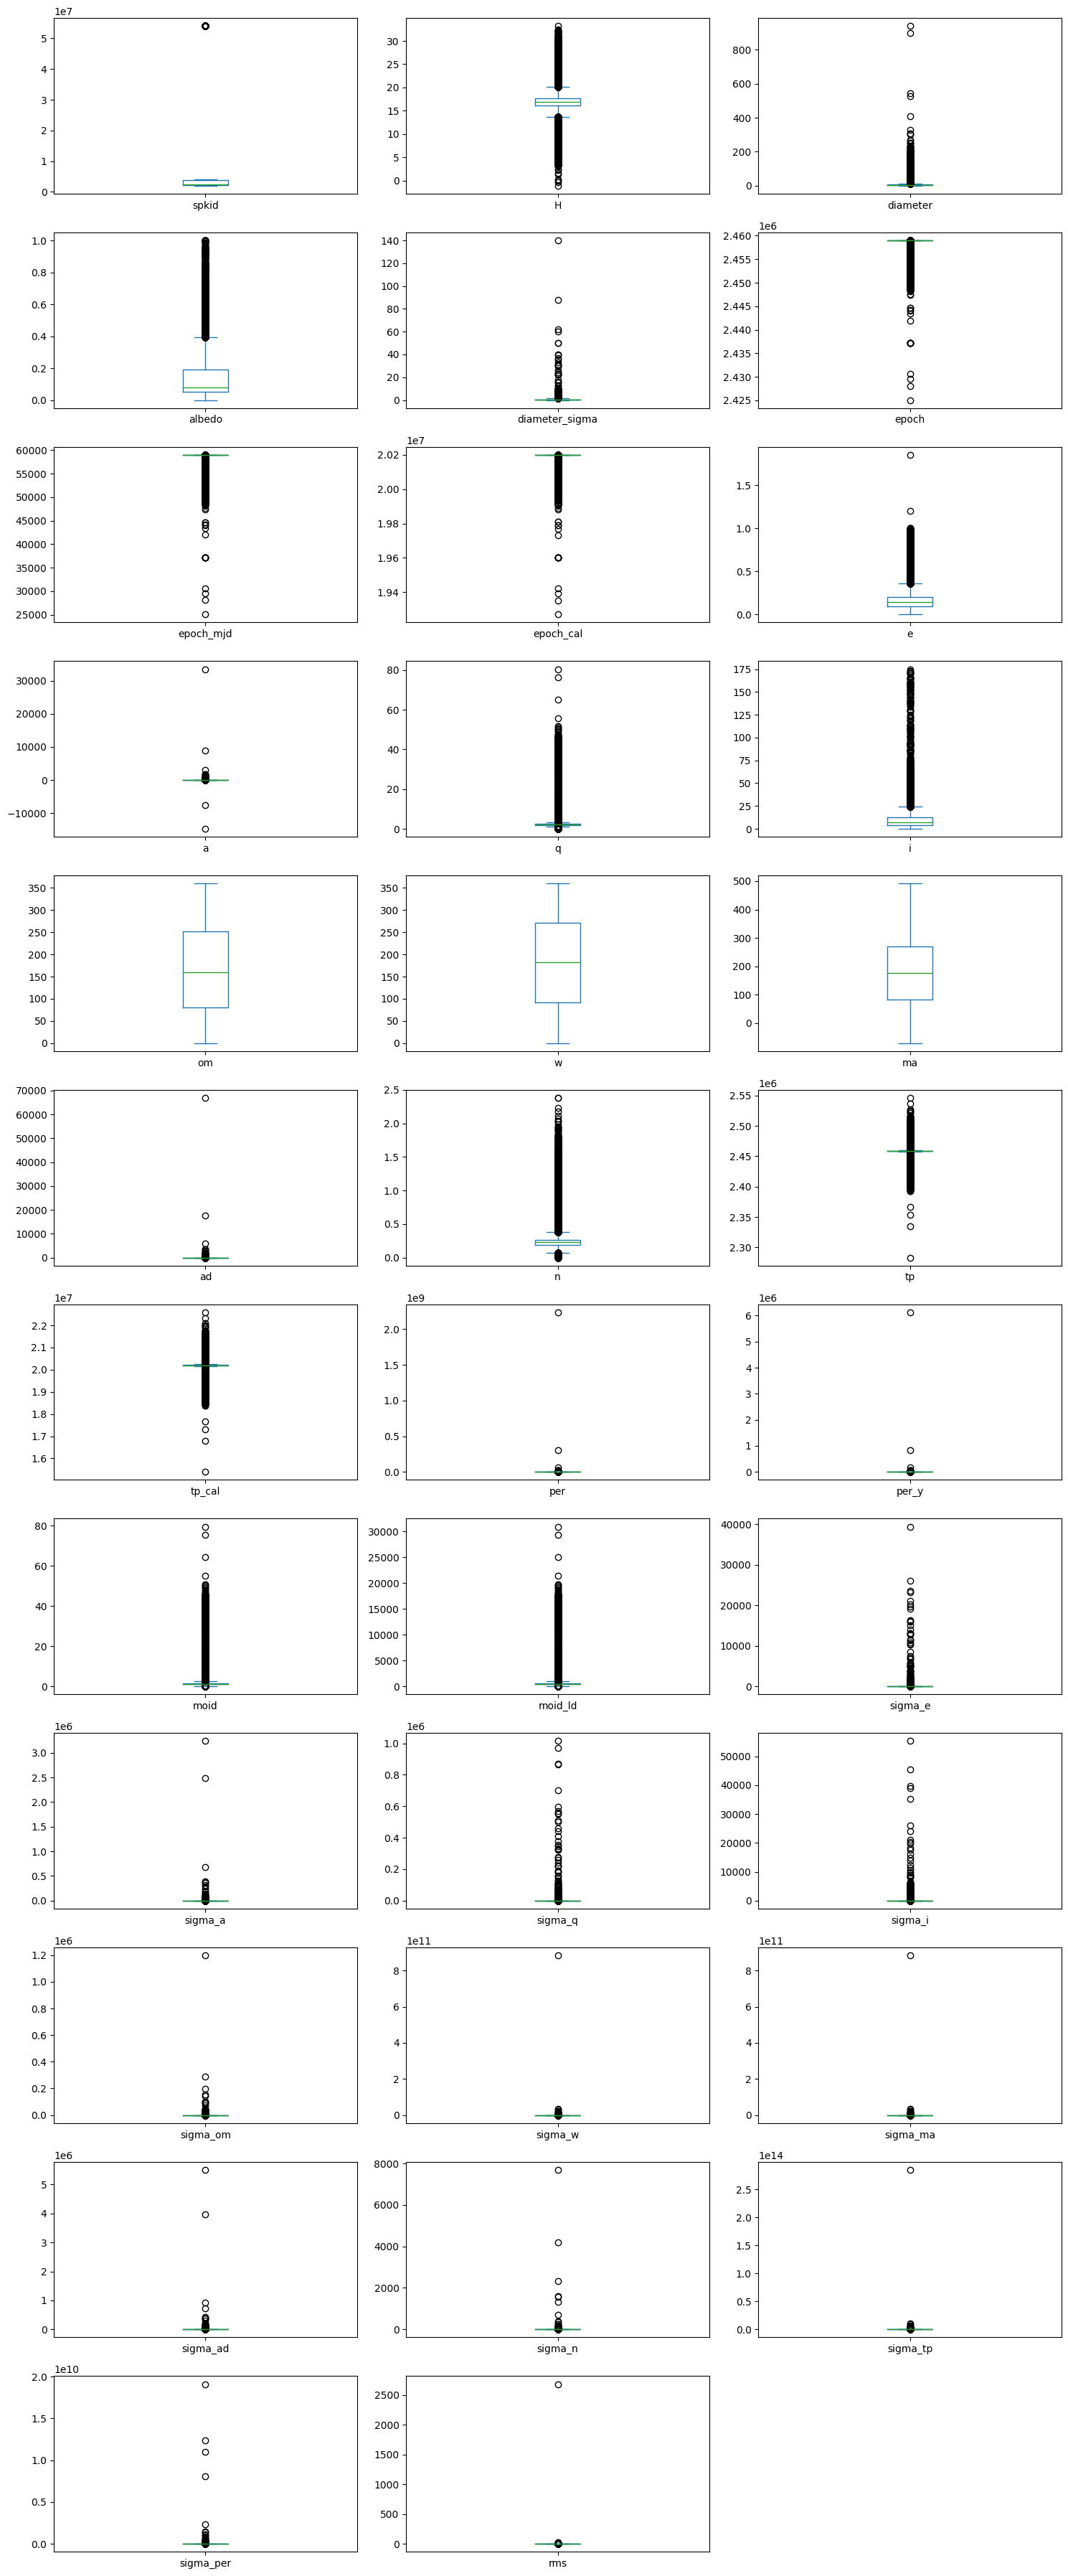

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=((len(num_cols) + 2) // 3, 3),
    figsize=(15, ((len(num_cols) + 2) // 3) * 3),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()

#Understanding the target variable

In [ ]:
print(df["diameter"].head())

0    939.400
1    545.000
2    246.596
3    525.400
4    106.699
Name: diameter, dtype: float64


In [ ]:
print(df["diameter"].dtype)

float64


In [ ]:
print(
    "Missing diameter values:",
    df["diameter"].isnull().sum()
)

Missing diameter values: 822315


In [ ]:
df = df.dropna(
    subset=["diameter"]
)

print(df.shape)

(136209, 45)


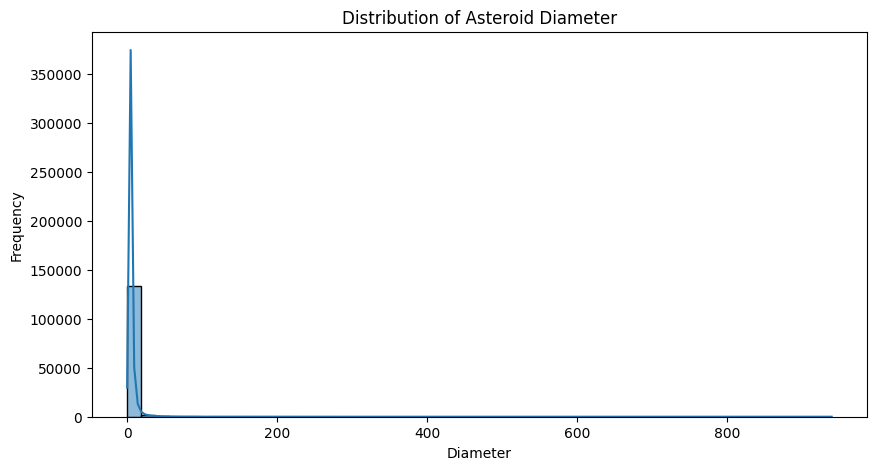

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["diameter"],
    bins=50,
    kde=True
)

plt.title("Distribution of Asteroid Diameter")
plt.xlabel("Diameter")
plt.ylabel("Frequency")

plt.show()

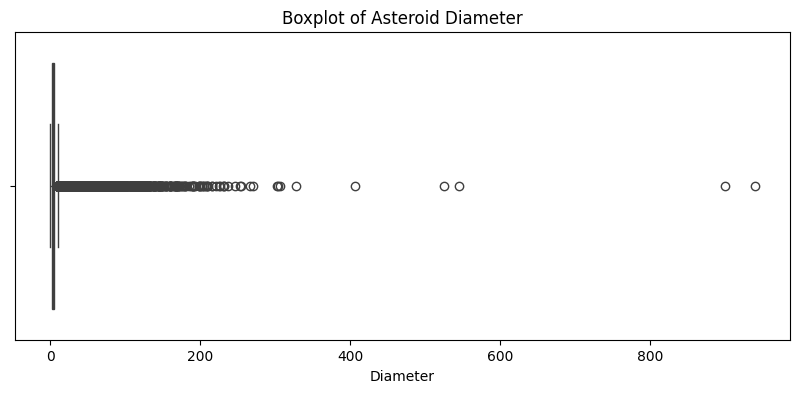

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["diameter"]
)

plt.title("Boxplot of Asteroid Diameter")
plt.xlabel("Diameter")

plt.show()

In [ ]:
correlation = df[numerical_columns].corr()

diameter_correlation = (
    correlation["diameter"]
    .sort_values(
        ascending=False
    )
)

print(diameter_correlation)

diameter          1.000000
diameter_sigma    0.337145
moid              0.331983
moid_ld           0.331983
q                 0.329223
a                 0.146799
ad                0.094735
epoch_cal         0.058539
epoch             0.058475
epoch_mjd         0.058475
i                 0.054963
per_y             0.050282
per               0.050282
tp_cal            0.013350
tp                0.013128
w                 0.003115
om                0.001530
ma               -0.002811
sigma_tp         -0.009043
sigma_ma         -0.009806
sigma_w          -0.009857
sigma_i          -0.017378
sigma_q          -0.019447
sigma_e          -0.020864
sigma_per        -0.022720
sigma_ad         -0.023295
sigma_a          -0.023531
sigma_om         -0.024879
sigma_n          -0.025989
e                -0.050649
spkid            -0.095362
albedo           -0.108880
rms              -0.182322
n                -0.199425
H                -0.572648
Name: diameter, dtype: float64


#CORERELATION

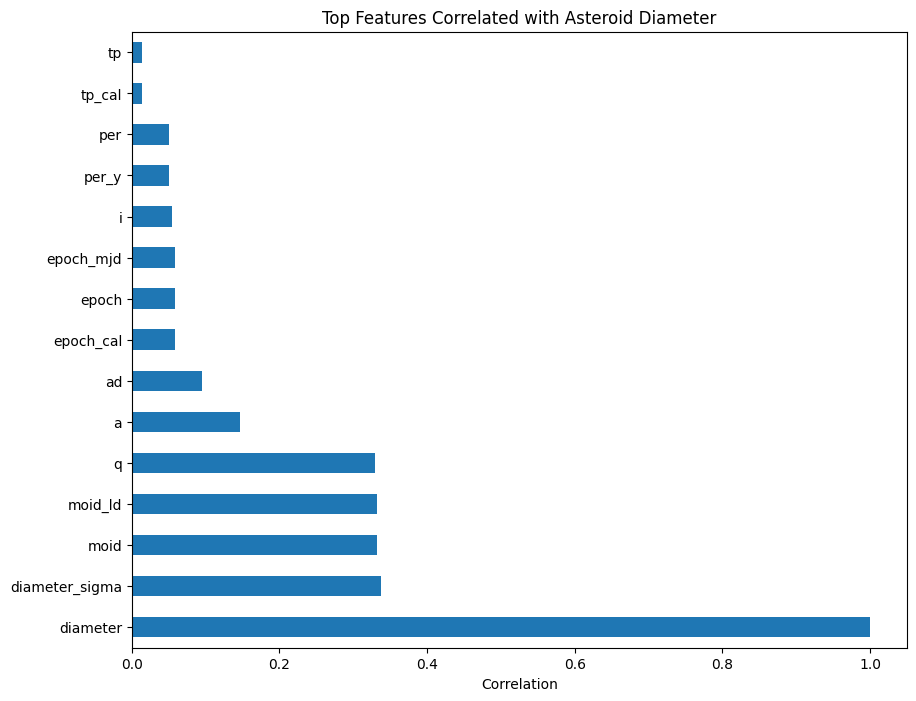

In [ ]:
plt.figure(figsize=(10, 8))

diameter_correlation.head(15).plot(
    kind="barh"
)

plt.title(
    "Top Features Correlated with Asteroid Diameter"
)

plt.xlabel("Correlation")

plt.show()

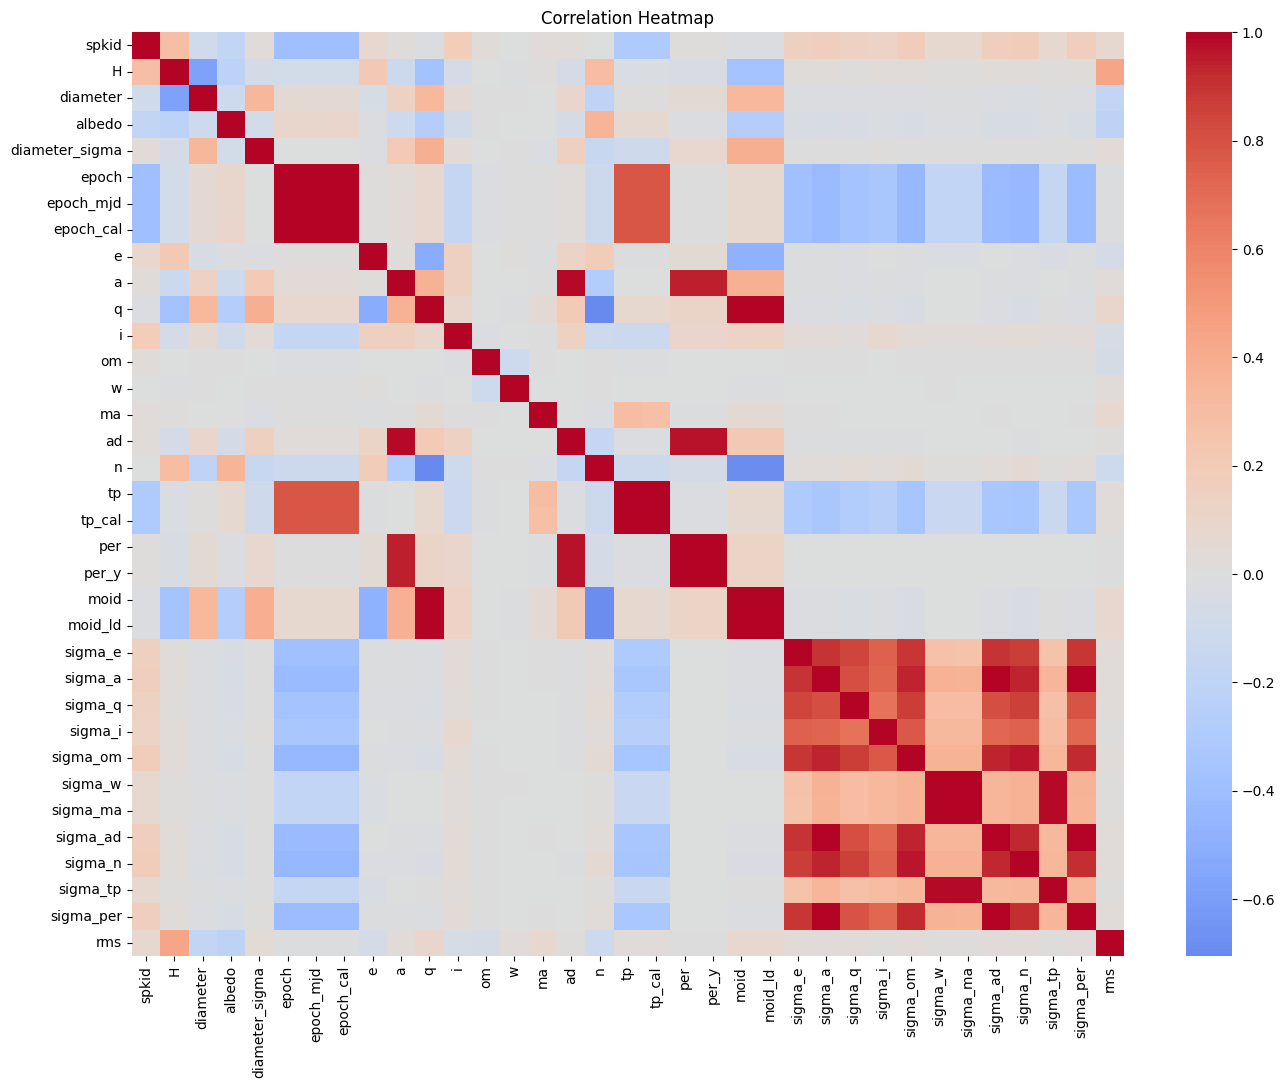

In [ ]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

#CREATE TARGET AND FEATURES

In [ ]:

y = df["diameter"]

X = df.select_dtypes(
    include=["int64", "float64"]
).copy()

In [ ]:
X = X.drop(
    columns=["diameter"],
    errors="ignore"
)

In [ ]:
#removing the identifier columns
columns_to_remove = [
    "spkid",
    "diameter_sigma"
]

X = X.drop(
    columns=columns_to_remove,
    errors="ignore"
)

In [ ]:
print("Features used:")
print(X.columns.tolist())

Features used:
['H', 'albedo', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']


#Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
imputer = SimpleImputer(
    strategy="median"
)

In [ ]:
X_train = imputer.fit_transform(
    X_train
)

In [ ]:
X_test = imputer.transform(
    X_test
)

#Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [ ]:
target_scaler = StandardScaler()

In [ ]:
y_train_scaled = target_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
)

y_test_scaled = target_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train_scaled.shape)
print("y_test:", y_test_scaled.shape)

X_train: (108967, 32)
X_test: (27242, 32)
y_train: (108967, 1)
y_test: (27242, 1)


#TASK 3

#DEEP NEURAL NETWORK

In [ ]:
#DNN REGRESSION MODEL
model = Sequential()

In [ ]:
#1st hidden layer
model.add(
    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#2nd hidden layer
model.add(
    Dense(
        32,
        activation="relu"
    )
)

In [ ]:
#3rd hidden layer
model.add(
    Dense(
        16,
        activation="relu"
    )
)

In [ ]:
#dropout
model.add(
    Dropout(0.3)
)

In [ ]:
#output layer
model.add(
    Dense(
        1,
        activation="linear"
    )
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
#early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
#train the dnn
history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.20,
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5732 - mae: 0.2252 - val_loss: 0.1629 - val_mae: 0.1346
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2937 - mae: 0.1601 - val_loss: 0.1042 - val_mae: 0.1242
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3732 - mae: 0.1406 - val_loss: 0.0628 - val_mae: 0.0905
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1998 - mae: 0.1274 - val_loss: 0.0694 - val_mae: 0.0931
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1895 - mae: 0.1258 - val_loss: 0.0477 - val_mae: 0.0833
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1466 - mae: 0.1213 - val_loss: 0.0458 - val_mae: 0.0778
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1313 - mae: 0.1173 - val_loss: 0.0435 - val_mae: 0.0788
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1259 - mae: 0.1160 - val_loss: 0.0494 - val_mae: 0.0867
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

#training vs validation

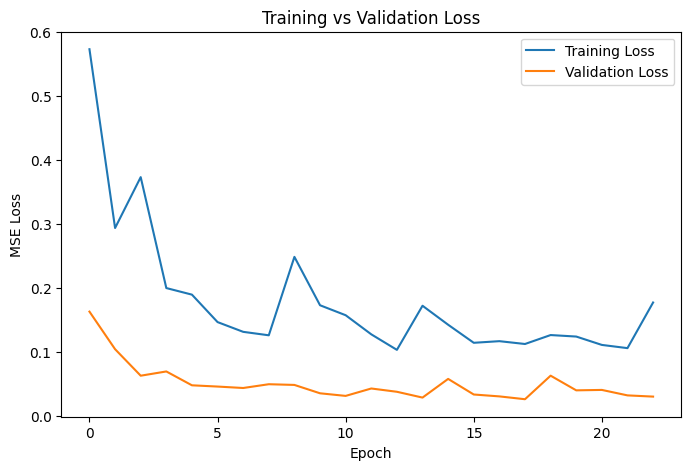

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

#Training vs validation mae

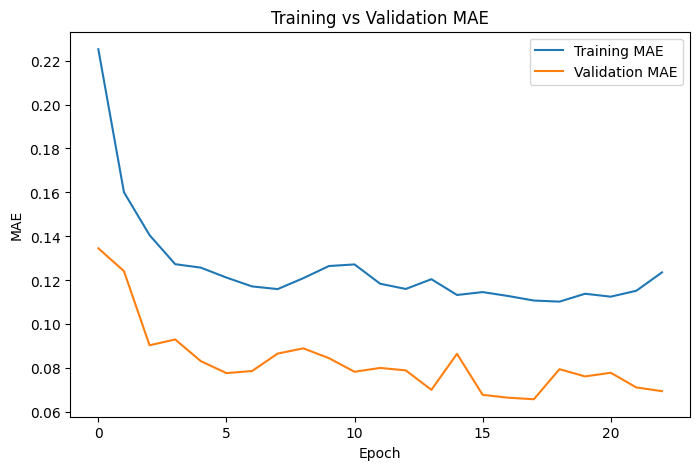

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("Training vs Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()

plt.show()

#ANALYTICAL

In [ ]:
1. STANDARD SCALING,
2
3. CORERALTION HELP US TO IDENTIFY HOW MUCH 2 NUMERICAL VALUES ARE COREREALETD WITH EACGOTHER

ANALYTICAL

In [ ]:
1 STANDARD SCALING
2 "spkid",
    "diameter_sigma" REMOVED THEM BECAUSE THEY ARE IDENTIFIER COLUMN
3 MY MODEL EXIBHITED OVERFITTING

#TASK 4

#Evaluate the model

In [ ]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test_scaled,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0887 - mae: 0.0679
Test Loss: 0.0887315645813942
Test MAE: 0.06791002303361893


In [ ]:
y_pred_scaled = model.predict(                          #make predictions
    X_test
)

852/852 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred = target_scaler.inverse_transform(
    y_pred_scaled
)

In [ ]:
y_pred = y_pred.ravel()

In [ ]:
y_actual = y_test.to_numpy()

#MAE

In [ ]:
mae = mean_absolute_error(
    y_actual,
    y_pred
)

print("MAE:", mae)

MAE: 0.6291163379011485


#MSE

In [ ]:
mse = mean_squared_error(
    y_actual,
    y_pred
)

print("MSE:", mse)

MSE: 7.61503122284895


#RMSE

In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2.7595346025822813


#r2 SCORE

In [ ]:
r2 = r2_score(
    y_actual,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.9245139835124596


In [ ]:

print("DNN REGRESSION RESULTS")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

DNN REGRESSION RESULTS
MAE  : 0.6291163379011485
MSE  : 7.61503122284895
RMSE : 2.7595346025822813
R²   : 0.9245139835124596


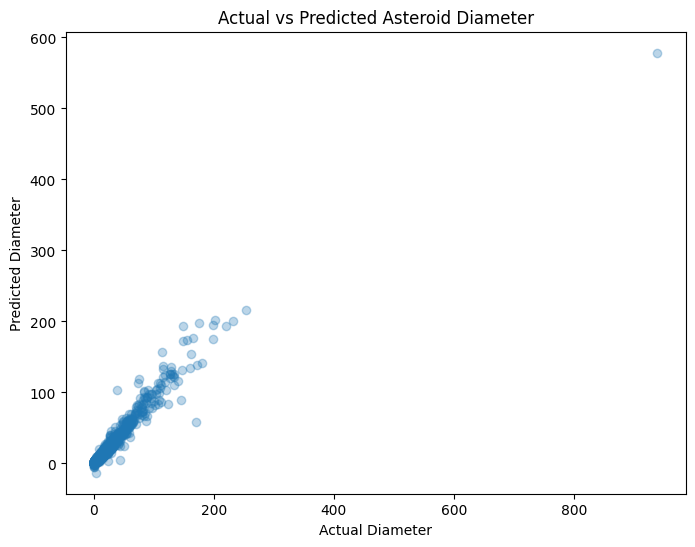

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Diameter")
plt.ylabel("Predicted Diameter")

plt.title(
    "Actual vs Predicted Asteroid Diameter"
)

plt.show()

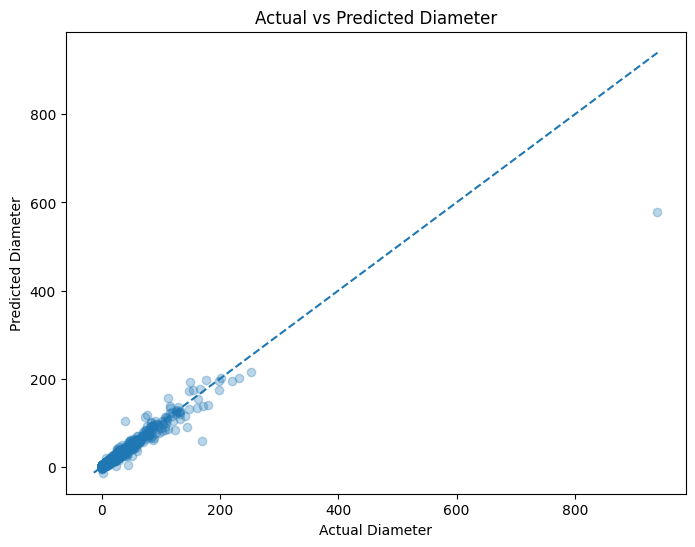

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.3
)

min_value = min(
    y_actual.min(),
    y_pred.min()
)

max_value = max(
    y_actual.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Diameter")
plt.ylabel("Predicted Diameter")

plt.title(
    "Actual vs Predicted Diameter"
)

plt.show()

In [ ]:
residuals = y_actual - y_pred

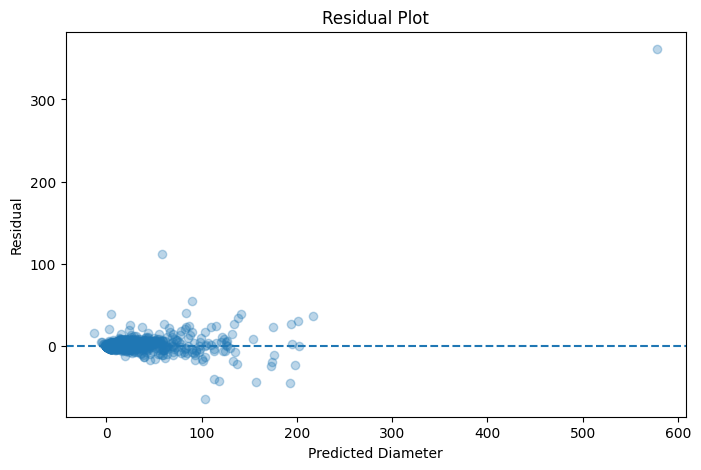

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Diameter")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

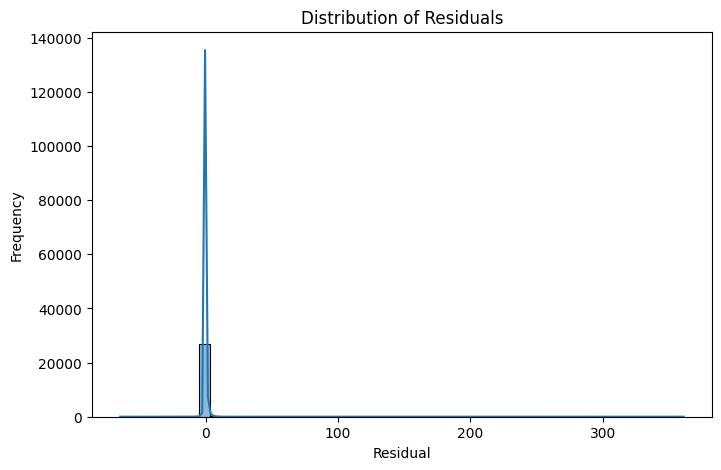

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual Diameter": y_actual,
    "Predicted Diameter": y_pred,
    "Residual": residuals
})

results.head(20)

,Actual Diameter,Predicted Diameter,Residual
0,2.509,3.033024,-0.524024
1,8.049,8.163224,-0.114224
2,2.363,2.393548,-0.030548
3,10.382,9.438382,0.943618
4,1.783,2.123333,-0.340333
5,2.934,3.283863,-0.349863
6,3.160,3.258770,-0.098770
7,1.736,1.901432,-0.165432
8,3.643,3.295779,0.347221
9,2.130,2.605466,-0.475466


#ANALYTICAL

In [ ]:
1.RMSE tells you how far the predicted asteroid diameters are from the actual diameters, with larger errors receiving more penalty.
2.We observe random scaterr
3.The difficult-to-predict asteroids are identified using the absolute residual. Asteroids with larger absolute residuals have a greater difference between their actual and predicted diameters, indicating that the DNN has more difficulty predicting their diameter.

#BONUS TASK

In [ ]:

# BASELINE DNN

def build_baseline_dnn(input_features):

    model = Sequential([

        Input(shape=(input_features,)),

        Dense(
            64,
            activation="relu"
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(
            1,
            activation="linear"
        )
    ])

    return model

In [ ]:
baseline_model = build_baseline_dnn(
    X_train.shape[1]
)

In [ ]:
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:

# TRAIN BASELINE DNN


start_time = time.time()

baseline_history = baseline_model.fit(
    X_train,
    y_train_scaled,

    validation_split=0.20,

    epochs=50,

    batch_size=256,

    verbose=1
)

baseline_training_time = time.time() - start_time

print(
    "Baseline training time:",
    baseline_training_time,
    "seconds"
)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4793 - mae: 0.1935 - val_loss: 0.1630 - val_mae: 0.1499
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2085 - mae: 0.1236 - val_loss: 0.0846 - val_mae: 0.1008
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1626 - mae: 0.1046 - val_loss: 0.0708 - val_mae: 0.0987
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2053 - mae: 0.1011 - val_loss: 0.1177 - val_mae: 0.0974
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2246 - mae: 0.0973 - val_loss: 0.0735 - val_mae: 0.0926
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1254 - mae: 0.0886 - val_loss: 0.0454 - val_mae: 0.0827
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0764 - mae: 0.0794 - val_loss: 0.0425 - val_mae: 0.0815
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0854 - mae: 0.0781 - val_loss: 0.0353 - val_mae: 0.0716
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [ ]:

# BASELINE PREDICTIONS

baseline_pred_scaled = baseline_model.predict(
    X_test,
    verbose=0
)

# Convert back to original diameter units
baseline_pred = target_scaler.inverse_transform(
    baseline_pred_scaled
).ravel()

actual_diameter = y_test.to_numpy()

In [ ]:

# BASELINE RMSE

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_diameter,
        baseline_pred
    )
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 1.984020937780575


In [ ]:
# BASELINE R2

baseline_r2 = r2_score(
    actual_diameter,
    baseline_pred
)

print("Baseline R²:", baseline_r2)

Baseline R²: 0.960979994944867


In [ ]:
baseline_mae = mean_absolute_error(
    actual_diameter,
    baseline_pred
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 0.5122489067539326


In [ ]:
# IMPROVED DNN WITH REGULARIZATION


def build_improved_dnn(input_features):

    model = Sequential([

        Input(shape=(input_features,)),

        # First hidden layer
        Dense(
            128,
            activation="relu",
            kernel_regularizer=l2(0.001)
        ),

        BatchNormalization(),

        Dropout(0.30),


        # Second hidden layer
        Dense(
            64,
            activation="relu",
            kernel_regularizer=l2(0.001)
        ),

        BatchNormalization(),

        Dropout(0.30),


        # Third hidden layer
        Dense(
            32,
            activation="relu",
            kernel_regularizer=l2(0.001)
        ),

        Dropout(0.20),


        # Regression output
        Dense(
            1,
            activation="linear"
        )
    ])

    return model

In [ ]:
improved_model = build_improved_dnn(
    X_train.shape[1]
)

In [ ]:
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
improved_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
#TRAIN IMPROVED DNN

start_time = time.time()

improved_history = improved_model.fit(
    X_train,
    y_train_scaled,

    validation_split=0.20,

    epochs=50,

    batch_size=256,

    callbacks=[early_stopping],

    verbose=1
)

improved_training_time = time.time() - start_time

print(
    "Improved training time:",
    improved_training_time,
    "seconds"
)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9958 - mae: 0.4481 - val_loss: 0.5294 - val_mae: 0.2213
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6151 - mae: 0.2435 - val_loss: 0.3652 - val_mae: 0.1799
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5166 - mae: 0.1943 - val_loss: 0.2982 - val_mae: 0.1681
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4660 - mae: 0.1688 - val_loss: 0.2346 - val_mae: 0.1470
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3948 - mae: 0.1532 - val_loss: 0.2301 - val_mae: 0.1236
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3847 - mae: 0.1472 - val_loss: 0.1754 - val_mae: 0.1115
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3847 - mae: 0.1402 - val_loss: 0.4622 - val_mae: 0.1574
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3285 - mae: 0.1370 - val_loss: 0.2362 - val_mae: 0.1204
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [ ]:
#IMPROVED PREDICTION

improved_pred_scaled = improved_model.predict(
    X_test,
    verbose=0
)

improved_pred = target_scaler.inverse_transform(
    improved_pred_scaled
).ravel()

In [ ]:
#rmse


improved_rmse = np.sqrt(
    mean_squared_error(
        actual_diameter,
        improved_pred
    )
)

print("Improved RMSE:", improved_rmse)

Improved RMSE: 4.235157783644086


In [ ]:
#improved r2
improved_r2 = r2_score(
    actual_diameter,
    improved_pred
)

print("Improved R²:", improved_r2)

Improved R²: 0.8221990778632469


In [ ]:
improved_mae = mean_absolute_error(
    actual_diameter,
    improved_pred
)

print("Improved MAE:", improved_mae)

Improved MAE: 0.7935060320813699


In [ ]:
# MODEL COMPARISON

comparison = pd.DataFrame({

    "Model": [
        "Baseline DNN",
        "Improved DNN"
    ],

    "RMSE": [
        baseline_rmse,
        improved_rmse
    ],

    "R2 Score": [
        baseline_r2,
        improved_r2
    ],

    "MAE": [
        baseline_mae,
        improved_mae
    ],

    "Training Time (sec)": [
        baseline_training_time,
        improved_training_time
    ],

    "Parameters": [
        baseline_model.count_params(),
        improved_model.count_params()
    ],

    "Layers": [
        len(baseline_model.layers),
        len(improved_model.layers)
    ]
})

comparison

,Model,RMSE,R2 Score,MAE,Training Time (sec),Parameters,Layers
0,Baseline DNN,1.984021,0.960980,0.512249,47.521936,4225,3
1,Improved DNN,4.235158,0.822199,0.793506,35.988709,15361,9


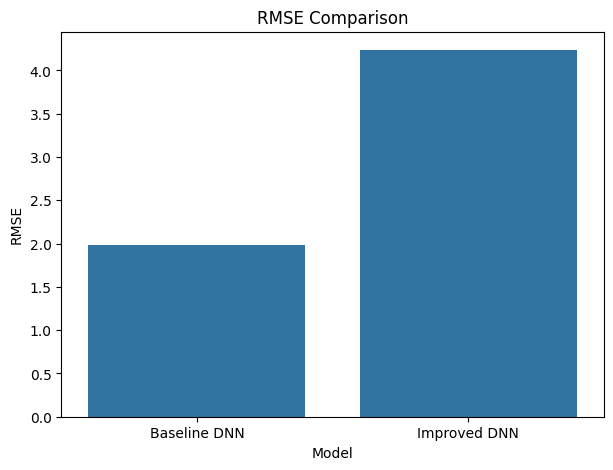

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.show()

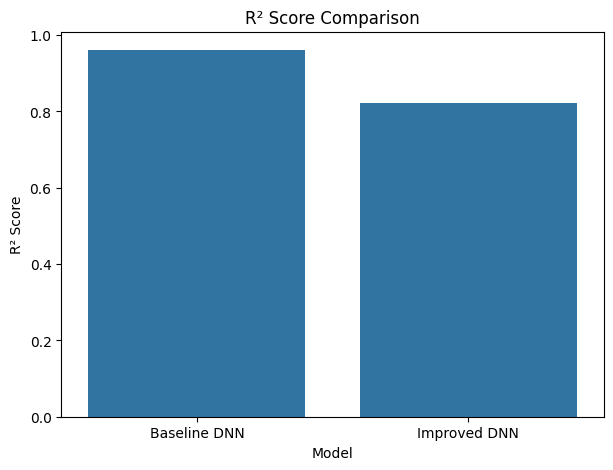

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.show()

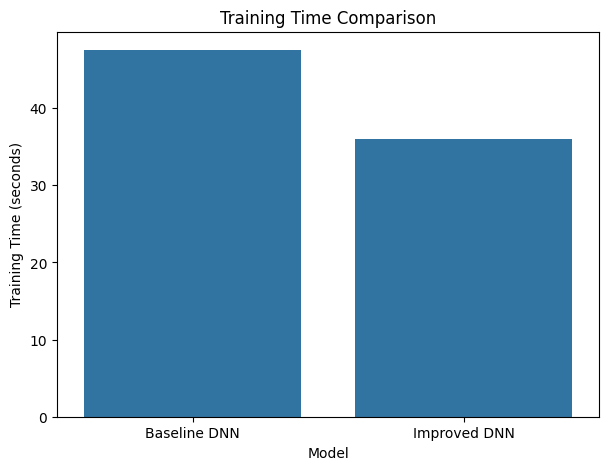

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Training Time (sec)"
)

plt.title("Training Time Comparison")
plt.ylabel("Training Time (seconds)")
plt.xlabel("Model")

plt.show()

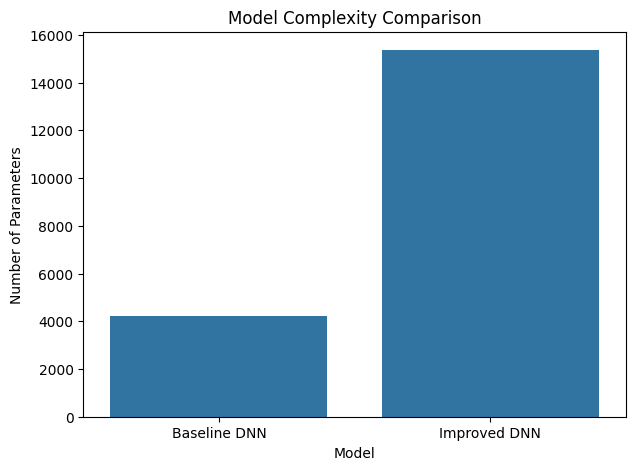

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Parameters"
)

plt.title("Model Complexity Comparison")
plt.ylabel("Number of Parameters")
plt.xlabel("Model")

plt.show()

#BASELINE

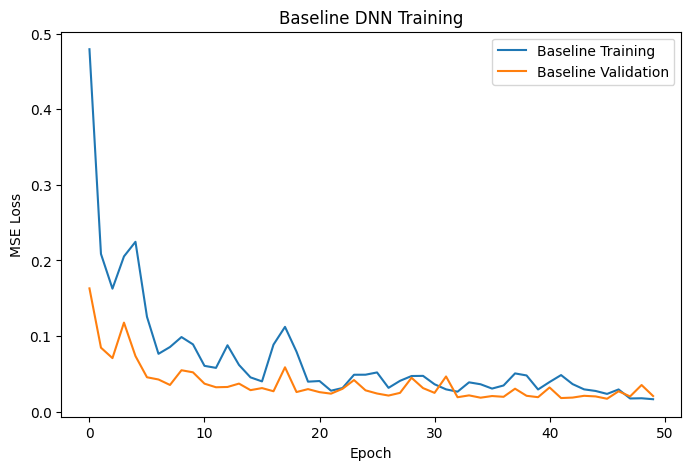

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Baseline Training"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Baseline Validation"
)

plt.title("Baseline DNN Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

#improved

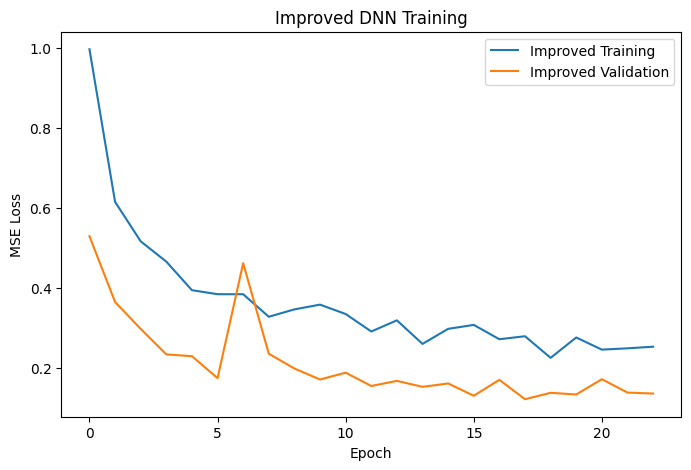

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["loss"],
    label="Improved Training"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Improved Validation"
)

plt.title("Improved DNN Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

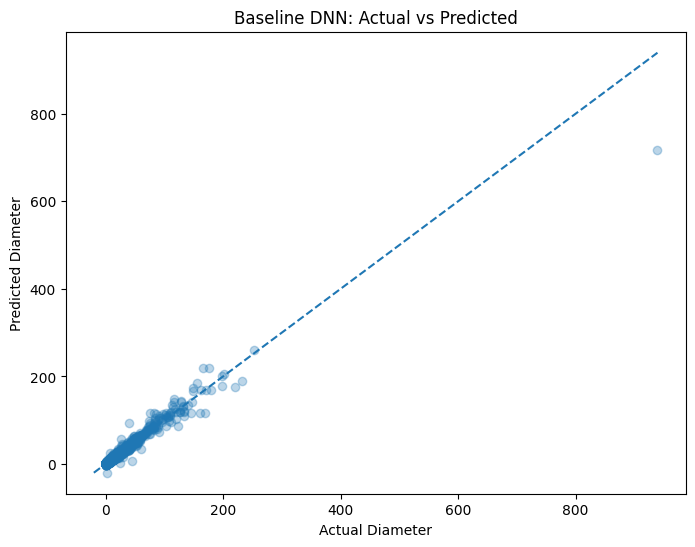

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual_diameter,
    baseline_pred,
    alpha=0.3
)

min_value = min(
    actual_diameter.min(),
    baseline_pred.min()
)

max_value = max(
    actual_diameter.max(),
    baseline_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Diameter")
plt.ylabel("Predicted Diameter")

plt.title(
    "Baseline DNN: Actual vs Predicted"
)

plt.show()

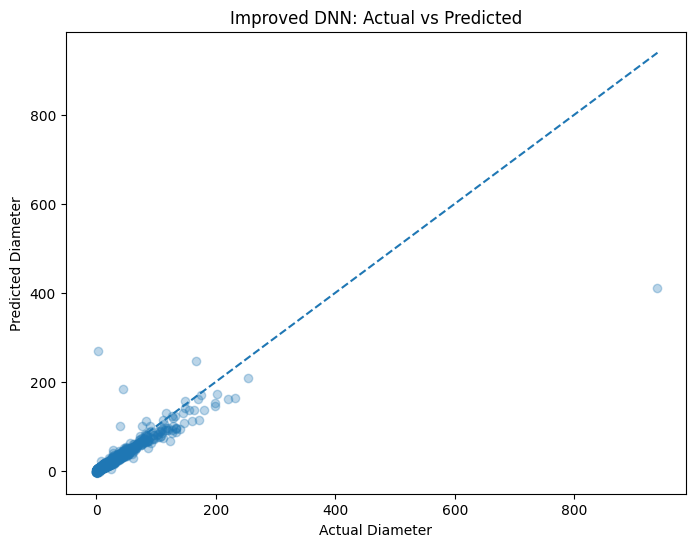

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual_diameter,
    improved_pred,
    alpha=0.3
)

min_value = min(
    actual_diameter.min(),
    improved_pred.min()
)

max_value = max(
    actual_diameter.max(),
    improved_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Diameter")
plt.ylabel("Predicted Diameter")

plt.title(
    "Improved DNN: Actual vs Predicted"
)

plt.show()

In [ ]:
print("FINAL MODEL COMPARISON")

print(comparison)

print("\nBaseline RMSE :", baseline_rmse)
print("Improved RMSE :", improved_rmse)

print("\nBaseline R² :", baseline_r2)
print("Improved R² :", improved_r2)

print(
    "\nBaseline training time:",
    baseline_training_time,
    "seconds"
)

print(
    "Improved training time:",
    improved_training_time,
    "seconds"
)

print(
    "\nBaseline parameters:",
    baseline_model.count_params()
)

print(
    "Improved parameters:",
    improved_model.count_params()
)

FINAL MODEL COMPARISON
          Model      RMSE  R2 Score       MAE  Training Time (sec)  \
0  Baseline DNN  1.984021  0.960980  0.512249            47.521936   
1  Improved DNN  4.235158  0.822199  0.793506            35.988709   

   Parameters  Layers  
0        4225       3  
1       15361       9  

Baseline RMSE : 1.984020937780575
Improved RMSE : 4.235157783644086

Baseline R² : 0.960979994944867
Improved R² : 0.8221990778632469

Baseline training time: 47.52193641662598 seconds
Improved training time: 35.98870897293091 seconds

Baseline parameters: 4225
Improved parameters: 15361


In [ ]:
BASELINE DNN is the better model for deployment because it has lower rmse and higher r2 score

In [ ]:
# Save the trained DNN model
improved_model.save("asteroid_dnn_model.keras")

In [ ]:
import pickle

# Save X imputer
with open("x_imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)

# Save X scaler
with open("x_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save target scaler
with open("y_scaler.pkl", "wb") as f:
    pickle.dump(target_scaler, f)

In [ ]:
http://localhost:8501/